# Checking if a cut on Xc_Y_SEP is useful

## Setting up the data and tools

In [2]:
%run load-rds-finalnobysepcut-2012-23903000-rs.ipynb

Loading data from /media/lben/Samsung_T7/data/eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/output
Loaded rdf with 880338 entries


In [3]:
import pandas as pd
import categories4 as f

In [6]:
def mygroupby(d, groupbycols):
    g = d.groupby(groupbycols).size().reset_index(name='count').sort_values([ 'count'], ascending=False).reset_index(drop=True)
    g["Percentage"] = g.apply(lambda row: 100 * row["count"]/d.shape[0], axis=1)
    g["cumulative %"] = g["Percentage"].cumsum(axis = 0)
    return g

## Basic statistics

In [10]:
rdf = f.add_categories_and_filter(rdf)

In [11]:
dfsep = pd.DataFrame(rdf.Cache(['category', 'simplified', 'B_M', 'B_Y_SEP', 'Xc_signal_Ypis_displaced_fromBs_fromTau', 'fromY_from_B_vertex', 'Xc_Y_SEP']).AsNumpy())

In [17]:
dfsep['simplified_key'] = dfsep.apply(lambda row: f.pretty_categories_map[row["simplified"]], axis=1)
dfsep['key'] = dfsep.apply(lambda row: f.categories_map[row["category"]], axis=1)

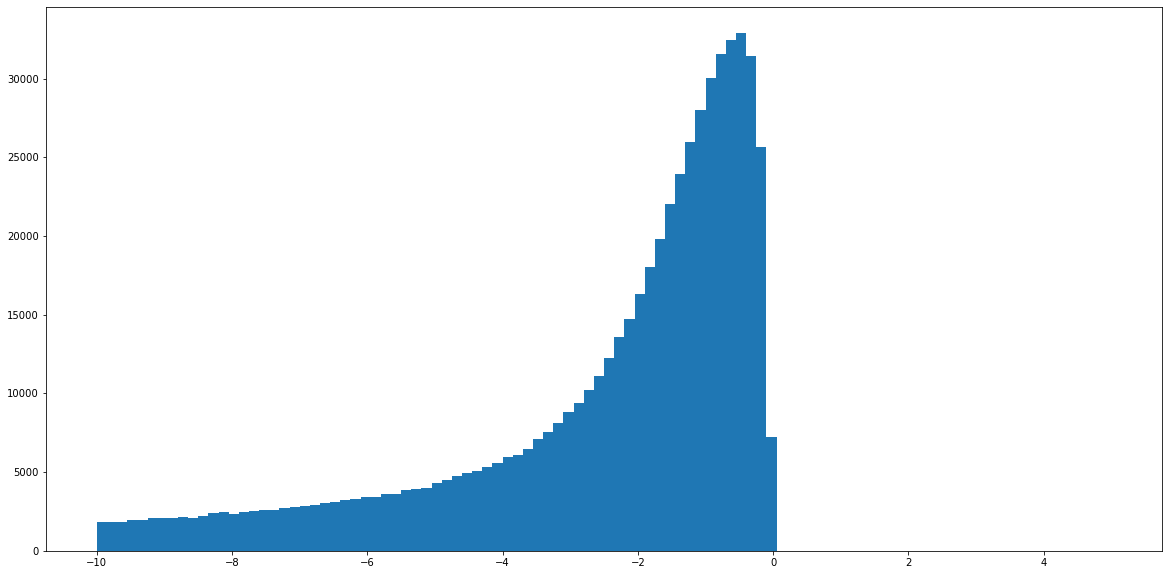

In [25]:
plt.hist(dfsep.B_Y_SEP, bins=100, range=[-10, 5]);

# Now cutting

In [26]:
dfsepcut = dfsep.query("B_Y_SEP < -4.5")

# Xc_Y_SEP after B_Y_SEP cut

In [27]:
gs = mygroupby(dfsepcut, "simplified_key")

In [28]:
gs

,simplified_key,count,Percentage,cumulative %
0,Double Charm,211882,87.287633,87.287633
1,Bad Xc,21459,8.840323,96.127956
2,Signal,3567,1.469474,97.597429
3,Normalization like,2729,1.124248,98.721678
4,Combinatorial,1764,0.726703,99.448381
5,Tau from charm,1113,0.458515,99.906896
6,Other displaced,178,0.073329,99.980226
7,Uncategorized,48,0.019774,100.000000


['Double Charm', 'Bad Xc', 'Signal', 'Normalization like', 'Combinatorial', 'Tau from charm', 'Other displaced', 'Uncategorized']


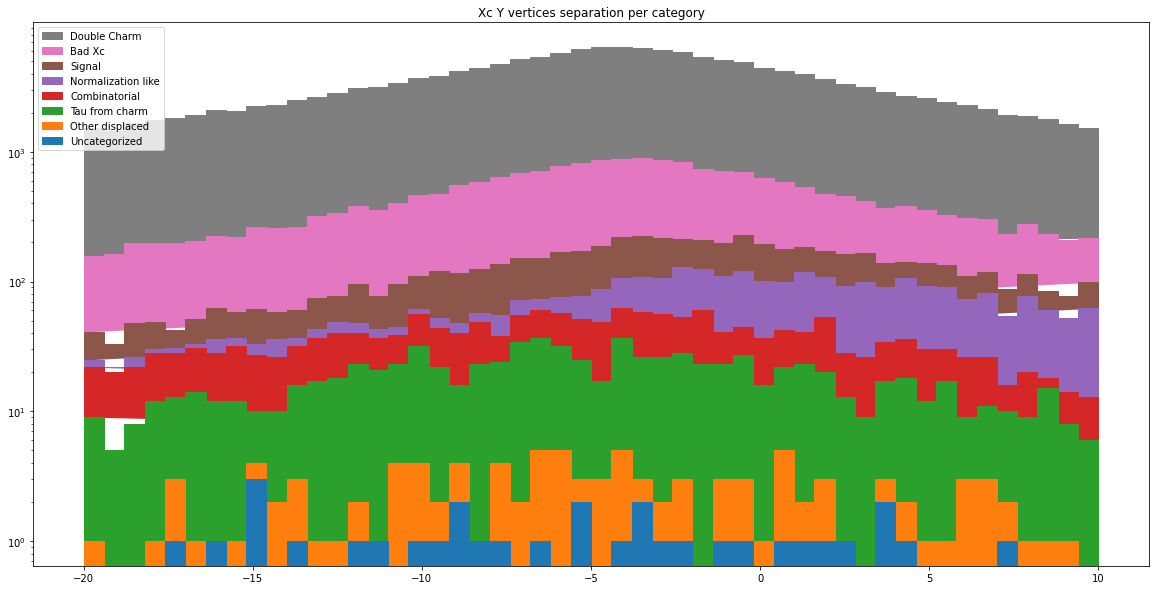

In [35]:
nbbins  = 50
myrange = [-20, 10]
categories_sorted = list(gs['simplified_key'])
print(categories_sorted)
datasets = [ dfsepcut.query(f"simplified_key == '{x}'").Xc_Y_SEP for x in reversed(categories_sorted)]
plt.hist(datasets, bins=nbbins, range=myrange, histtype='step', label= list(reversed(categories_sorted)) , stacked=True,  fill=True)
plt.yscale("log")
plt.title("Xc Y vertices separation per category")
plt.legend(loc='upper left')
plt.savefig("XcYsep_per_category_stacked_Iso_BDT_cut.png",  bbox_inches='tight');

In [40]:
%%time
filename = "XcYSEP_temp.root"
if not os.path.exists(filename):
    rdf.Filter("B_Y_SEP < -4.5").Snapshot("DecayTree", "XcYSEP_temp.root", ['category', 'simplified', 'B_M', 'B_Y_SEP', 'Xc_signal_Ypis_displaced_fromBs_fromTau', 'fromY_from_B_vertex', 'Xc_Y_SEP'])

CPU times: user 844 µs, sys: 31 µs, total: 875 µs
Wall time: 4.85 ms


In [43]:
import math
def cut_xc_y_sep(cuts):
    foms = []
    for cutval in cuts:
        rdfcut = ROOT.RDataFrame("DecayTree", filename)
        res = rdfcut.Filter(f"Xc_Y_SEP < {cutval}", "sepcut").Filter("Xc_signal_Ypis_displaced_fromBs_fromTau == 1", "signal")
        r = res.Report().GetValue()
        #print(f"=== cut: Xc_Y_SEP < {cutval}")
        #r.Print()
        c = r['signal']
        signal_count = c.GetPass()
        
        resfromBvtx = rdfcut.Filter(f"Xc_Y_SEP < {cutval}", "sepcut").Filter("fromY_from_B_vertex", "bvtx")
        r = resfromBvtx.Report().GetValue()
        #r.Print()
        c = r['bvtx']
        background_count = c.GetPass()

        fom = signal_count/ math.sqrt(signal_count + background_count)
        foms.append(fom)
        print("FOM: %s", fom)
    return foms


cuts = np.arange(-7, 5, 0.1)
foms = cut_xc_y_sep(cuts)


Evaluating the cuts without the B_M cut on the dataset
FOM: %s 30.725878683173256
FOM: %s 30.968313622122388
FOM: %s 31.11449715799702
FOM: %s 31.228089566632978
FOM: %s 31.388959646009333
FOM: %s 31.61053315671238
FOM: %s 31.814912580945673
FOM: %s 32.03671879814397
FOM: %s 32.28475251656561
FOM: %s 32.42500192095762
FOM: %s 32.59525603659198
FOM: %s 32.75258012083786
FOM: %s 33.02857142857143
FOM: %s 33.2107633495511
FOM: %s 33.52602650551973
FOM: %s 33.72350493830624
FOM: %s 33.903589100471365
FOM: %s 34.09736261041756
FOM: %s 34.335272361577566
FOM: %s 34.58105296179954
FOM: %s 34.79649483254857
FOM: %s 34.971096653609095
FOM: %s 35.173190818488166
FOM: %s 35.4834290332129
FOM: %s 35.667067167536565
FOM: %s 35.88392984004159
FOM: %s 36.01518923319769
FOM: %s 36.25445680599658
FOM: %s 36.47005159879199
FOM: %s 36.60973220209873
FOM: %s 36.75422211733612
FOM: %s 36.90393869750305
FOM: %s 37.231465005128804
FOM: %s 37.32094290709506
FOM: %s 37.49940418206217
FOM: %s 37.72048932743411


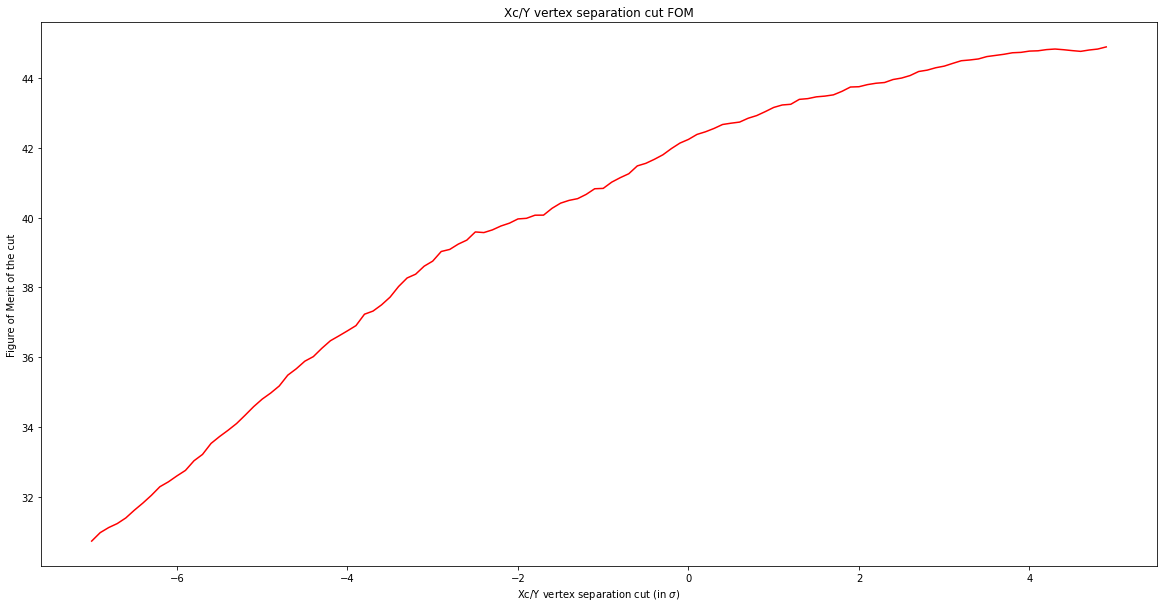

In [44]:
plt.figure()
plt.tight_layout()
plt.plot(cuts, foms, "-r", label="FOM ")
plt.ylabel("Figure of Merit of the cut")
plt.xlabel("Xc/Y vertex separation cut (in $\sigma$)")
#plt.legend()
#plt.axvline(-4.5)
plt.title("Xc/Y vertex separation cut FOM")
plt.savefig("XcY_fom.png")
